In [2]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 6]

In [4]:
# COSTANTI
m, L, g = 1, 1, 9.81
theta0, omega0 = 0.5, 0.0
t1, t2, t3, h = 20, 500, 10, 0.01
gL = g/L
ver_color = "#ed184d"
rk4_color = "#187bed"

In [5]:
times = np.arange(0, t1, h)
long_times = np.arange(0, t2, h)
hs = np.array([0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001])

# Introduzione
In caso si voglia studiare l'evoluzione di sistemi meccanici, cioè caratterizzati da una posizione e una velocità, un metodo molto utile per l'integrazione delle equazioni del moto è quello di Verlet. Il suo vantaggio consiste nell'essere un metodo **simplettico**, cioè obbedisce al teorema di Liouville e quindi conserva il volume nello spazio delle fasi e di conseguenza conserva l'energia. Viene generalmente utilizzato per sistemi in cui l'accelerazione non dipende dall'energia, cioè non abbiamo componenti dissipative.

La derivazione del metodo di Verlet si basa sul principio di minima azione di Hamilton e a differenza del metodo di Eulero e di Runge-Kutta, questo metodo calcolo sia la posizione all'instante successivo che quella all'istante precedente: questo meccanismo offre una maggiore precisione a scapito di essere un metodo *non autoavviante*, infatti bisogna calcolare un passo iniziale con un altro metodo. Infine, l'errore globale presentato dal metodo di Verlet è $O(h^2)$ sia per la velocità che per la posizione.

Durante tutta la simulazione utilizzeremo la variante **Velocity Verlet** che calcola posizione e velocità in modo sincrono, infatti se per Verlet abbiamo:
$$x_{k+1} = 2x_k - x_{k-1} + h^2 a(x_k, t_k)$$
$$v_{k} = \frac{x_{k+1}-x_{k-1}}{2h},$$
per Velocity-Verlet abbiamo:
$$x_{k+1}=x_k + hv_k + \frac{h^2}{2}a_k$$
$$v_{k+1}=v_k + \frac{h}{2}(a_k + a_{k+1}).$$

Confronteremo i risultati con il metodo di Runge-Kutta 4 che, a differenza di Velocity-Verlet e Verlet, non è un metodo simplettico e quindi non conserva l'energia. Nonostante questo è un metodo ampiamente utilizzato perché è uno dei più stabili per simulazioni molto lunghe. Il problema di RK4 consiste nel più alto costo computazionale, infatti per ogni passo temporale dobbiamo calcolare 4 punti.

In [6]:
def verlet(theta0: float, h: float, times: list[float]) -> tuple[list[float], list[float]]:
    """
    Implementazione Velocity-Verlet:
        calcoliamo preventivamente le quantità h/2 e h**2/2 per ottimizzare il codice ed evitare di computare 
        due moltiplicazioni ad ogni ciclo. Per l'implementazione vengono usati gli array di numpy che permettono
        di allocare la memoria necessaria senza utilizzare gli array dinamici di Python.
    """
    a0 = -gL * np.sin(theta0)
    h_mezzi, h_quadro_mezzi = h/2, h**2/2
    pos, vel = np.zeros(len(times)), np.zeros(len(times))
    pos[0], vel[0] = theta0, omega0

    for i in range(1, len(times)):
        pos[i] = pos[i-1] + h * vel[i-1] + h_quadro_mezzi * a0
        a = -gL * np.sin(pos[i])
        vel[i] = vel[i-1] + h_mezzi * (a0 + a)

        a0 = a

    return pos, vel

def rk4(theta0: float, h: float, times: list[float]) -> tuple[list[float], list[float]]:
    h_mezzi, h_sesti = h/2, h/6
    pos, vel = np.zeros(len(times)), np.zeros(len(times))
    pos[0], vel[0] = theta0, omega0

    for i in range(1, len(times)):
        k1t, k1o = vel[i-1], -gL * np.sin(pos[i-1])
        k2t, k2o = vel[i-1] + h_mezzi * k1o, -gL * np.sin(pos[i-1] + h_mezzi * k1t)
        k3t, k3o = vel[i-1] + h_mezzi * k2o, -gL * np.sin(pos[i-1] + h_mezzi * k2t)
        k4t, k4o = vel[i-1] + h * k3o, -gL * np.sin(pos[i-1] + h * k3t)

        pos[i] = pos[i-1] + h_sesti * (k1t + 2*k2t + 2*k3t + k4t)
        vel[i] = vel[i-1] + h_sesti * (k1o + 2*k2o + 2*k3o + k4o)
        
    return pos, vel

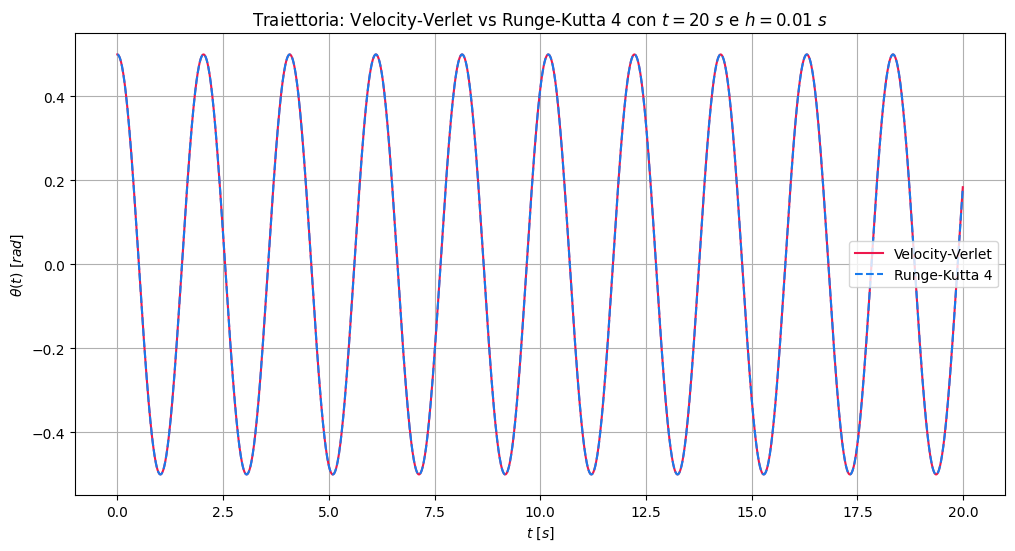

In [7]:
ver_pos, ver_vel = verlet(theta0=theta0, h=h, times=times)
rk4_pos, rk4_vel = rk4(theta0=theta0, h=h, times=times)

plt.plot(times, ver_pos, color=ver_color, label="Velocity-Verlet")
plt.plot(times, rk4_pos, "--", color=rk4_color, label="Runge-Kutta 4")
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$\theta(t)\ [rad]$")
plt.grid()
plt.legend()
plt.title(r"Traiettoria: Velocity-Verlet vs Runge-Kutta 4 con $t=20\ s$ e $h=0.01\ s$")
plt.show()

# Analisi delle simulazioni
Dal grafico notiamo che i due metodi per tempi di simulazione brevi (in questo caso specifico abbiamo $t=20\ s$) sono indistinguibili e quindi la scelta di uno o dell'altro metodo è irrilevante a meno di non dover calcolare un numero di punti tale da rendere RK4 una scelta poco affrontabile dal punto di vista computazionale.

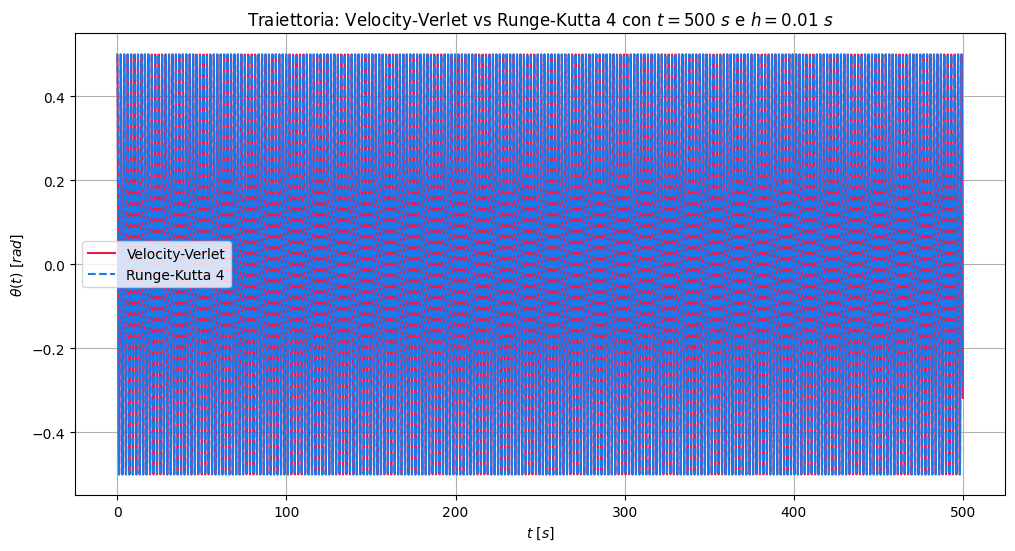

In [8]:
l_ver_pos, l_ver_vel = verlet(theta0=theta0, h=h, times=long_times)
l_rk4_pos, l_rk4_vel = rk4(theta0=theta0, h=h, times=long_times)

plt.plot(long_times, l_ver_pos, color=ver_color, label="Velocity-Verlet")
plt.plot(long_times, l_rk4_pos, "--", color=rk4_color, label="Runge-Kutta 4")
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$\theta(t)\ [rad]$")
plt.grid()
plt.legend()
plt.title(rf"Traiettoria: Velocity-Verlet vs Runge-Kutta 4 con $t={t2}\ s$ e $h={h}\ s$")
plt.show()

Nonostante abbiamo ampliato il tempo di simulazione di un fattore $25$, passando da $t=20\ s$ a $t=500\ s$, le due integrazioni continuano a essere praticamente indistinguibili.

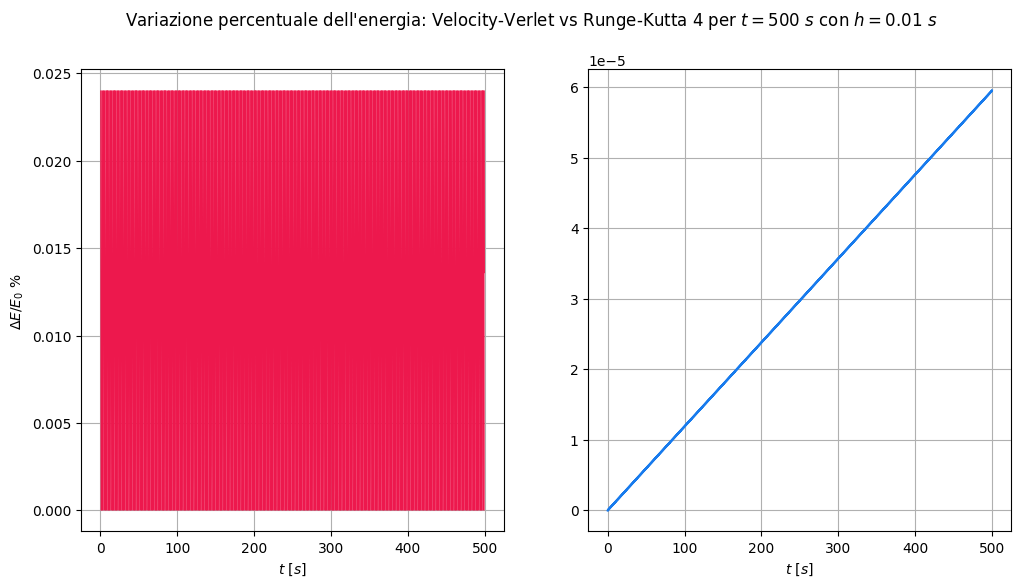

In [13]:
# ENERGIE
ver_energy = 0.5 * m * L**2 * l_ver_vel**2 + m * g * L * (1 - np.cos(l_ver_pos))
rk4_energy = 0.5 * m * L**2 * l_rk4_vel**2 + m * g * L * (1 - np.cos(l_rk4_pos))
energy = [0.5 * m * L**2 * omega0**2 + m * g * L * (1 - np.cos(theta0)) for _ in long_times]

delta_ver_energy = abs(ver_energy - energy)
delta_rk4_energy = abs(rk4_energy - energy)

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(long_times, 100*delta_ver_energy/energy, color=ver_color, label="Velocity-Verlet", lw=0.3)
ax1.set_xlabel(r"$t\ [s]$")
ax1.set_ylabel(r"$\Delta E/E_0\ \%$")
ax1.grid(True)

ax2.plot(long_times, 100*delta_rk4_energy/energy, color=rk4_color, label="Runge-Kutta 4")
ax2.set_xlabel(r"$t\ [s]$")
ax2.grid(True)

plt.suptitle(rf"Variazione percentuale dell'energia: Velocity-Verlet vs Runge-Kutta 4 per $t={t2}\ s$ con $h={h}\ s$")
plt.show()

Nella simulazione della variazione percentuale dell'energia troviamo conferma simulativa alla teoria: il metodo di Velocity-Verlet conserva meglio l'energia rispetto a Runge-Kutta 4. Infatti, nonostante siano evidenti delle oscillazioni nel grafico a sinistra, analizzando la scala sull'asse delle ascisse si può facilmente constatare che l'ampiezza delle oscillazioni è di qualche centesimo di punto percentuale attorno ad un valore praticamente nullo. Al contrario, il metodo di Runge-Kutta 4 mostra che su un tempo di simulazione non molto grande ($t=500\ s$) mostra una variazione di energia netta. Stiamo comunque parlando di ordini di $10^-5$ ma questo mette in luce i contro di questo metodo.

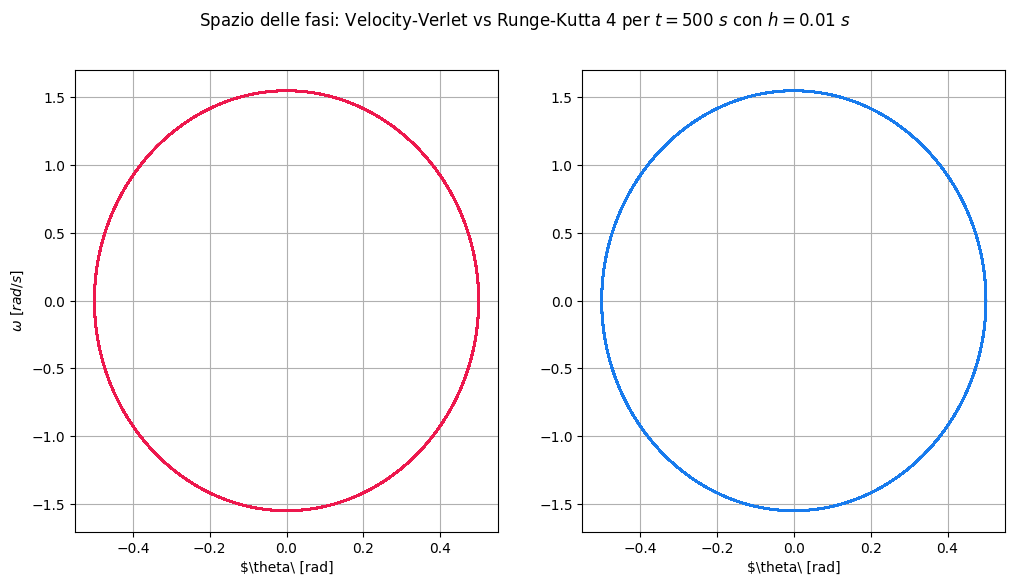

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(l_ver_pos, l_ver_vel, color=ver_color, label="Velocity-Verlet")
ax1.set_xlabel(r"$\theta\ [rad]")
ax1.set_ylabel(r"$\omega\ [rad/s]$")
ax1.grid(True)

ax2.plot(l_rk4_pos, l_rk4_vel, color=rk4_color, label="Runge-Kutta 4")
ax2.set_xlabel(r"$\theta\ [rad]")
ax2.grid(True)

plt.suptitle(rf"Spazio delle fasi: Velocity-Verlet vs Runge-Kutta 4 per $t={t2}\ s$ con $h={h}\ s$")
plt.show()

Passando allo spazio delle fasi notiamo che le figure sono praticamente sovrapponibili e questo è dovuto al fatto che la scala del grafico non permette di vedere le piccole oscillazioni del ritratto di fase prodotto da RK4: il metodo non è simplettico e quindi non conserva l'energia. Nonostante questo, non vediamo la variazione del volume nello spazio delle fasi perché RK4 ha un errore globale $O(h^4)$ e quindi dovremmo simulare per un tempo $t^*$ tale che $t^* > 1/(h^4)$ che nel nostro caso specifico corrisponderebbe a $t^*=10^8\ s$.

In [11]:
def compute_error(hs: list[float], f: callable, camp: float) -> list[float]:
    errs = np.zeros(len(hs))
    for i in range(len(hs)):
        t = np.linspace(0, 10, int(10/hs[i])+1)
        pos, vel = f(theta0=theta0, h=hs[i], times=t)
        err = abs(pos[-1] - camp)
        errs[i] = err

    return errs

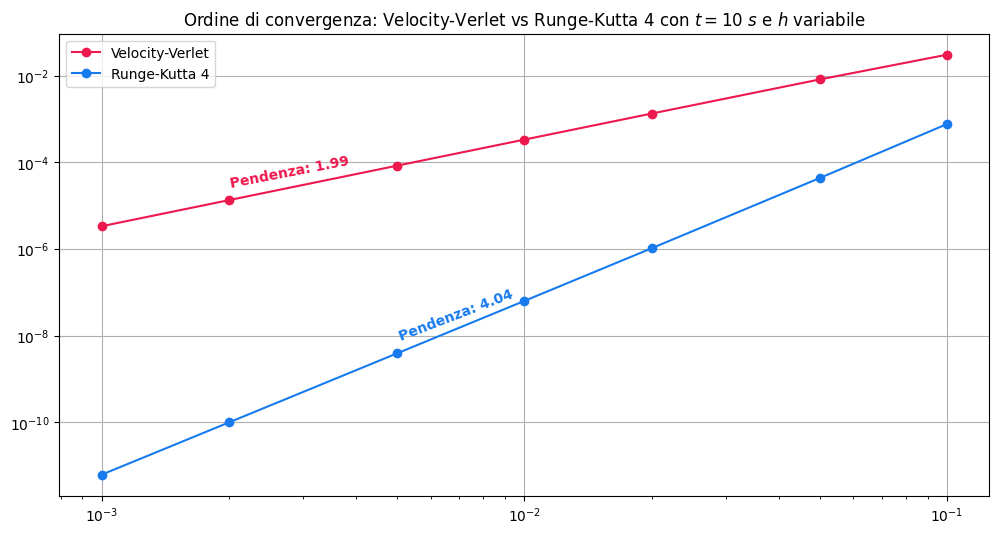

In [12]:
t10 = np.linspace(0, 10, int(10/0.0001)+1)
rif, _ = rk4(theta0=theta0, h=0.0001, times=t10)
camp = rif[-1]

ver_err = compute_error(hs=hs, f=verlet, camp=camp)
rk4_err = compute_error(hs=hs, f=rk4, camp=camp)
log_h, log_ver_err, log_rk4_err = np.log(hs), np.log(ver_err), np.log(rk4_err)

m_ver, _ = np.polyfit(log_h, log_ver_err, 1)
m_rk4, _ = np.polyfit(log_h, log_rk4_err, 1)

plt.plot(hs, ver_err, "-o", color=ver_color, label="Velocity-Verlet")
plt.plot(hs, rk4_err, "-o", color=rk4_color, label="Runge-Kutta 4")
plt.text(hs[-2], ver_err[-2]*2, f"Pendenza: {m_ver:.2f}", color=ver_color, fontweight="bold", rotation=11)
plt.text(hs[-3], rk4_err[-3]*2, f"Pendenza: {m_rk4:.2f}", color=rk4_color, fontweight="bold", rotation=21)
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.legend()
plt.title(rf"Ordine di convergenza: Velocity-Verlet vs Runge-Kutta 4 con $t=10\ s$ e $h$ variabile")
plt.show()

# Conclusioni
Come abbiamo notato dalle simulazioni entrambi i metodi proposti sono molto affidabili per comuni sistemi meccanici e quindi la scelta è indifferente. Una scelta più oculata va fatta per situazioni più complesse in cui bisogna decidere se dare più peso alla stabilità per lunghe simulazioni (Runge-Kutta 4) o alla conservazione dell'energia del sistema (Velocity Verlet).